<a href="https://colab.research.google.com/github/Matheus0820/Aprendizado-de-Maquina/blob/main/unidade01/codes/Classificando_Iris_com_arvore_de_decis%C3%A3o_Unidade1_Aprendizado_de_Maquina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/Matheus0820/Aprendizado-de-Maquina/refs/heads/main/unidade01/datasets/Iris.csv"

df = pd.read_csv(url)
df.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Caracterizando as entradas e saida

### Entradas:
- SepalLengthCm
- SepalWidthCm
- PetalLengthCm
- PetalWidthCm

### Saída:
- Species

In [ ]:
# Matriz de Entradas
select_cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
X = df[select_cols].values
print(X[:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [ ]:
# Array de Saída
y = df["Species"].values
print(y[:5])

['Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa']


## Divisão entre valores de teste e de treino

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

print("X_train: ", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train: ", y_train.shape)
print("y_test: ", y_test.shape)

X_train:  (120, 4)
X_test:  (30, 4)
y_train:  (120,)
y_test:  (30,)


## Treinamento

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=4) # Criando o modelo com profundidade máxima de 3
model.fit(X_train, y_train) # Treinando o modelo

DecisionTreeClassifier(max_depth=4)

## Diagrama de Árvore Treinado

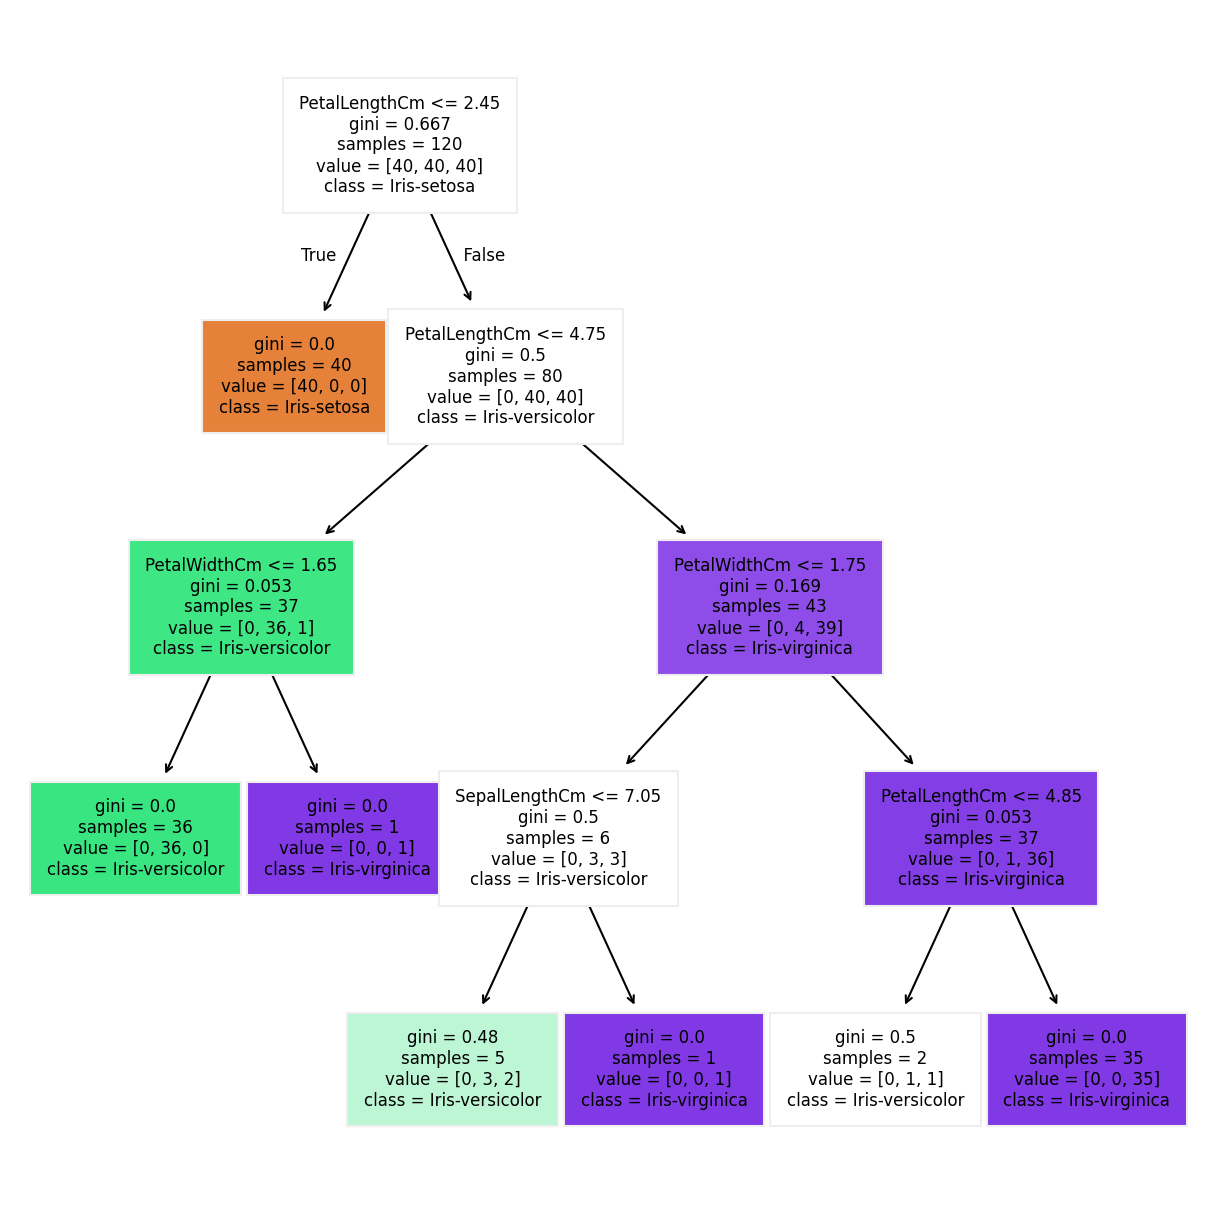

In [ ]:
# Importações
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Definindo estilo do gráfico -> Que vai ser o diagrama
plt.style.use("ggplot")

# Plotando diagram da árvore de decisão
fig, axe = plt.subplots(nrows= 1, ncols= 1, figsize = (5, 5), dpi = 300)
plot_tree(model,
          feature_names=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"],
          class_names=["Iris-setosa", "Iris-versicolor", "Iris-virginica"],
          filled=True,
          node_ids=False,
          fontsize=4)
plt.show()

## Avaliando modelo criado
O objetivo aqui é verificar se o nosso modelo está bem treinado e consegue acertar uma grande quantidade no teste.

In [ ]:
# Importando biblioteca
from sklearn.metrics import accuracy_score, confusion_matrix

# Fazendo as previsões de respostas para os dados de teste
y_pred = model.predict(X_test)

# Calculando a acurácia
acuracia = accuracy_score(y_test, y_pred)
print("Acurácia: ", acuracia)
print(f"Acurácia em porcetagem: {(acuracia*100):.2f}%")

# Calculando a matriz de confusão
matriz_confusao = confusion_matrix(y_test, y_pred)
print("\n","Matriz de Confusão: \n", matriz_confusao)

Acurácia:  0.9333333333333333
Acurácia em porcetagem: 93.33%

 Matriz de Confusão: 
 [[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]
